In [135]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from scipy.stats import laplace

# Setting up the data and initial exploration

In [156]:
# loading a real world data
data = load_breast_cancer(as_frame=True)
df = data.frame
print(df.head())

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst texture  worst perimeter  worst area  \
0             

In this dataset the target label 0 means malignant. I keep only the malignant patients (212) because I want to see how much privacy noise changes the statistics of patients who have cancer.

In [137]:
features = ['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness']
df_malignant = df[df['target'] == 0][features]
num_of_patients = len(df_malignant)

In [157]:
print(df_malignant.head())
print('Number of patients who have malignant tumor:' , num_of_patients)

   mean radius  mean texture  mean perimeter  mean area  mean smoothness
0        17.99         10.38          122.80     1001.0          0.11840
1        20.57         17.77          132.90     1326.0          0.08474
2        19.69         21.25          130.00     1203.0          0.10960
3        11.42         20.38           77.58      386.1          0.14250
4        20.29         14.34          135.10     1297.0          0.10030
Number of patients who have malignant tumor: 212


# Setting up data boundaries for Differential Privacy (DP)
- to calculate the global sensitivity, global boundaries must be set
- data boundaries `[Min, Max]` 
- we can't just use the `df.min()` and `df.max()` method to find the minimun and maximum boundaries becasue this can leak data
- so we can use the metadata from the dataset to setup the boundaries

The empirical ranges below come from the  WDBC dataset (569 records). I use them only as a guide, then round up to wider clean numbers. This was done to make things simplier for me in the project.

In [140]:
from ucimlrepo import fetch_ucirepo 
breast_cancer_wisconsin_diagnostic = fetch_ucirepo(id=17) 
X = breast_cancer_wisconsin_diagnostic.data.features 
summary_stats = X.describe().loc[['min', 'max']]
# Assuming your summary DataFrame is named 'summary'
target_features = ['radius1', 'texture1', 'perimeter1', 'area1', 'smoothness1']
summary = summary_stats[target_features]

# Rename columns to match your exact requested labels
summary.columns = ['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness']

print(summary)


     mean radius  mean texture  mean perimeter  mean area  mean smoothness
min        6.981          9.71           43.79      143.5          0.05263
max       28.110         39.28          188.50     2501.0          0.16340


# Choosing the upper and lower bound
- To cap the absolute max (Enfored Upper Bound), i chose to round it up to the next logical clean number to prevent the boundary limit themselves from leaking the individual traits
- For the absolute min the lower bound is zero for convenience and simplicity

| Feature Name     | Empirical Minimum | Empirical Maximum | Enforced DP Lower Bound | Enforced DP Upper Bound |
|-------------------|--------------------|--------------------|---------------------------|---------------------------|
| mean radius       | 6.98 mm            | 28.11 mm           | 0                          | 30.0 mm                   |
| mean texture       | 9.71               | 39.28              | 0                          | 40.0                       |
| mean perimeter     | 43.79 mm           | 188.50 mm          | 0                          | 200.0 mm                  |
| mean area          | 143.50 mm²         | 2501.00 mm²        | 0                          | 2800.0 mm²                |
| mean smoothness    | 0.05               | 0.16               | 0                          | 0.20                       |

**Sensitivity** represent the maximum amount of deviation in output statistical query that is caused by the addition or removal of any single individual's data

**General Formula for Global Sensitivity**

Δf = max‖f(D) − f(D′)‖

**Breakdown:**

- **Δf** — the global sensitivity of function *f*
- **f(D)** — the output of query/function *f* on dataset *D*
- **f(D′)** — the output of the same function on a neighboring dataset *D′* (differs from *D* by exactly one record — one addition, removal, or change)
- **‖ · ‖** — a norm (commonly the L1 or L2 norm), measuring the "distance" between the two outputs
- **max** — taken over **all possible neighboring dataset pairs** (D, D′) — sensitivity is the worst-case change, not the average case

**Intuition:** it answers *"If one person's data is added, removed, or changed, how much can the query's output possibly shift?"* This worst-case shift is what determines how much noise must be added to preserve privacy.


──────────────────────────────────────────────────────────────────────────────────────────

**Epsilon** represent the privacy budget that control how much privacy we want to enforce
Low epsilon means higher privacy and higher epsilon means lower privacy

**Noise Scale** represent the statistical randomness that is added to the output of a query to hide individual record identities

It is the ratio of the sensitivity and epsilon

Noise Scale = sensitivity / epsilon

──────────────────────────────────────────────────────────────────────────────────────────


[ High Sensitivity ] (Wide Data Range)  ┐  

                                    ├─► [ MASSIVE NOISE ADDED ] ──► (Low Data Accuracy)

[ Low Epsilon Budget ] (Strict Privacy) ┘

──────────────────────────────────────────────────────────────────────────────────────────

[ Low Sensitivity ] (Tight Data Range)  ┐   

                                    ├─► [ TINY NOISE ADDED ] ────► (High Data Accuracy)

[ High Epsilon Budget ] (Loose Privacy) ┘

### Sensitivities used (R = upper bound - lower bound)

I use replace-one neighbors, with n = 212 treated as public and values clipped to the bounds.

- **Mean:** one record can change the sum by at most R, and the mean divides by n, so sensitivity = R / n
- **Standard deviation:** std = (distance of the data from its mean) / sqrt(n). Changing one record moves that distance by at most R, so sensitivity = R / sqrt(n)
- **Quartiles (Q1, median, Q3):** in the worst case one record can move a quantile anywhere between the bounds, so sensitivity = R

Laplace noise scale = sensitivity / epsilon. Std and quartiles have much larger sensitivity than the mean, so they get much more noise.

In [171]:
# setting up boundaries and privacy budget
boundaries = {
    'mean radius':     (0.0, 30.0),    
    'mean texture':    (0.0, 40.0),    
    'mean perimeter':  (0.0, 200.0),   
    'mean area':       (0.0, 2800.0),  
    'mean smoothness': (0.0, 0.20)  
}

# Privacy budget for the analysis
total_epsilon = 1.0

# statistic query we are gonna calculate 
stat_query = ['Mean', 'Std Dev', 'Q1 (25th Pct)', 'Q2 (Median)', 'Q3 (75th Pct)']

- For the five feature, the 5 basic statistics (Mean, Standard Deviation, first quartile, Second Quartile(median) and Third Quartile) are calculated normally
- Again same metrics are measured after adding laplace noise on the result
- The noise scale is sensitivity / epsilon and I added this to both the numpy as well as my custom laplace function
- I also divided the privacy budget evenly among each query i.e. each query uses a part of the privacy budget and the parts adds up --> sequential composite theorem 
-  5 features x 5 statistics = 25 queries, so each gets epsilon = 1 / 25 = 0.04
- results are compared with the true values
- the difference is then plotted

**Note:** 
<u>Sequential Composite Theorem</u> tells us that every single query we do on the data leaks a bit of privacy and it all adds up linearly 

total privacy budget (total_epsilon) = epsilon_for_query1 + epsilon_for_quety2 + ... + epsilon_for_queryN


In [172]:
no_of_query = len(features) * len(stat_query) # 25 query becasue we have 5 features and 5 query to be performed on each feature

epsilon_per_query = total_epsilon / no_of_query

print(f"Total Records (Malignant):         {len(df_malignant)}")
print(f"Global Privacy Budget (ε):         {total_epsilon}")
print(f"Total Number Of Queries:           {no_of_query}")
print(f"Epsilon Used Per Query:        {epsilon_per_query:.3f}")

Total Records (Malignant):         212
Global Privacy Budget (ε):         1.0
Total Number Of Queries:           25
Epsilon Used Per Query:        0.040


## Creating a custom laplace function for this project
- i am generating a random laplace distribution curve and using a random point from this curve to add the noise to the data
- first two groups of random numbers are generated between 0 and 1 and it is stored in two varibales r1 and r2
- then we create a `scale` which is the sensitivity / privacy-budget
- scale determines the spread of the two laplace distribution curve
- a `size` is used to determine the number of unique noise data that is generated
- the function takes two variable the `scale` and `size`

In [173]:
# custom laplace noise function

def laplace_noise(scale, size):
    # generate a random distribution between 0 and 1 
    # generation range is between 0 to 1 because we use the log function later that only takes values between 0 and 1
    r1 = np.random.uniform(0, 1, size = size)
    r2 = np.random.uniform(0, 1, size = size)

    # creating an exponential curve using natural log
    # we use the negative scale value because np.log will give a negative number and the value for the expontial can never be negative
    # exponentialrandom sample must always be positive
    e1 = -scale * np.log(1.0 - r1)
    e2 = -scale * np.log(1.0 - r2)

    return e1 - e2

In [174]:
# keeping track of the base result, the result with Differential privacy applied and the deviations
base_results = {}
dp_results = {}
dp_with_custom_laplace = {}
deviations ={}
deviations_with_custom_laplace = {}

In [175]:
# keeping track of errors per trial
numpy_deviations_for_all = []
custom_deviations_for_all = []

In [176]:
# keeping track of each run / trial as the loop goes for 1000 iteration
# keep track of the raw DP values for each run
numpy_dp_for_all = []     
custom_dp_for_all = []

### Post-processing

Noise can push a result to go outside what is possible (negative std, quartile outside the bounds). Fixing this afterwards by clipping and sorting uses no extra privacy budget, because it only uses the noisy output and already established bounds

I repeat the whole experiment 1000 times only to measure how noisy the method is

In [177]:
# perform the same task 1000 times so we can get a more better result
for t in range(1000):
    for col in features:
        raw_data = df_malignant[col].values
        min_bound, max_bound = boundaries[col]
        # enforcing the clipping bound on the data
        data = np.clip(raw_data, min_bound, max_bound)

        # baseline statistics ---> no diffential priacy used
        # done using simply the numpy package

        base_mean = np.mean(data)
        base_std = np.std(data)
        base_q1 = np.percentile(data, 25)
        base_median = np.percentile(data, 50)
        base_q3 = np.percentile(data,75)

        base_results[col] = [base_mean, base_std, base_q1, base_median, base_q3]

    ###################################################################################################

        # computing the differential privacy statistics
        # noise added using the laplacian

        # mean sensitivity
        mean_sensitivity = (max_bound - min_bound) / num_of_patients

        mean_scale = mean_sensitivity / epsilon_per_query

        # adding noise to mean
        dp_mean = base_mean + np.random.laplace(0, mean_scale)
        dp_lap_mean = base_mean + laplace_noise(mean_scale, size=None)

        # std sensitivity
        std_sensitivity = (max_bound - min_bound) / (num_of_patients ** 0.5)

        std_scale =  std_sensitivity / epsilon_per_query
        # adding noise to the standard deviation
        dp_std = base_std + np.random.laplace(0,std_scale)
        dp_lap_std = base_std + laplace_noise(std_scale, size=None)

        # percentile sensitivity
        percentile_sensitivity = (max_bound - min_bound)
        percentile_scale = percentile_sensitivity / epsilon_per_query
        dp_q1 = base_q1 + np.random.laplace(0 , percentile_scale)
        dp_median = base_median + np.random.laplace(0 , percentile_scale)
        dp_q3 = base_q3 + np.random.laplace(0 , percentile_scale)

        dp_lap_q1 = base_q1 + laplace_noise(percentile_scale, size=None)
        dp_lap_median = base_median + laplace_noise(percentile_scale, size=None)
        dp_lap_q3 = base_q3 + laplace_noise(percentile_scale, size=None)


        ######################################################################################################################################################################################
        # post processing
        # since the laplace function uses random values and it does not know the mathematical constraints, the bound are being set for all the stat

        # the mean must fall within the absolute boundary of the data
        dp_mean = max(min_bound, min(max_bound, dp_mean))

        dp_lap_mean = max(min_bound, min(max_bound, dp_lap_mean))


        # standard deviation is never less than 0 because it ranges from 0 to infinity we make sure that our dp_std will never be less than 0
        dp_std = max(0.0, dp_std)
        dp_lap_std = max(0, dp_lap_std)

        # q1 can't be less than the absolute minimum
        dp_q1 = max(min_bound, min(max_bound, dp_q1))
        dp_lap_q1 = max(min_bound, min(max_bound, dp_lap_q1))

        # q3 can't be more than the absolute maximum
        dp_q3 = max(min_bound, min(max_bound, dp_q3))
        dp_lap_q3 = max(min_bound, min(max_bound, dp_lap_q3))

        # median stays inside the bounds
        dp_median = max(min_bound, min(max_bound, dp_median))
        dp_lap_median = max(min_bound, min(max_bound, dp_lap_median))

        # mathematically Q1 < Q2 < Q3
        # adding random noise can mess the order of this
        # we sort the result of applying noise in ascending order
        # then we assign it to Q1, Q2, Q3 based on how smalll or big the value is
        percentiles_sorted = sorted([dp_q1, dp_median, dp_q3])
        dp_q1     = percentiles_sorted[0] # get lowest
        dp_median = percentiles_sorted[1] # get middle
        dp_q3     = percentiles_sorted[2] # get highest

        percentiles_sorted_laplace = sorted([dp_lap_q1, dp_lap_median, dp_lap_q3])
        dp_lap_q1     = percentiles_sorted_laplace[0] # get lowest
        dp_lap_median = percentiles_sorted_laplace[1] # get middle
        dp_lap_q3     = percentiles_sorted_laplace[2] # get highest


        dp_results[col] = [dp_mean, dp_std, dp_q1, dp_median, dp_q3]

        dp_with_custom_laplace[col] = [dp_lap_mean, dp_lap_std, dp_lap_q1, dp_lap_median, dp_lap_q3]

        # calculating the deviaions between the normal baseline statistic and differential privacy one
        normal_stat = [base_mean, base_std, base_q1, base_median, base_q3]
        dp_stat = [dp_mean, dp_std, dp_q1, dp_median, dp_q3]
        dp_lap_stat = [dp_lap_mean, dp_lap_std, dp_lap_q1, dp_lap_median, dp_lap_q3]

        deviation = []

        deviation_custom_lap = []

        for normal_value, dp_value in zip(normal_stat, dp_stat):
            absolute_delta = abs(normal_value - dp_value)

            if normal_value != 0:
                percentage_delta = (absolute_delta / normal_value) * 100
            else:
                percentage_delta = 0
            
            deviation.append(percentage_delta)
        
        deviations[col] = deviation


        for normal_value, dp_value in zip(normal_stat, dp_lap_stat):
            absolute_delta = abs(normal_value - dp_value)

            if normal_value != 0:
                percentage_delta = (absolute_delta / normal_value) * 100
            else:
                percentage_delta = 0
            
            deviation_custom_lap.append(percentage_delta)
        
        deviations_with_custom_laplace[col] = deviation_custom_lap

    # append the errors of each run
    numpy_deviations_for_all.append({c: list(v) for c, v in deviations.items()})
    custom_deviations_for_all.append({c: list(v) for c, v in deviations_with_custom_laplace.items()})

    # append the actual values of each for each run
    numpy_dp_for_all.append({c: list(v) for c, v in dp_results.items()})
    custom_dp_for_all.append({c: list(v) for c, v in dp_with_custom_laplace.items()})
        


In [178]:
# using pandas we create dataframe tables for the base and the dp 

df_base_table = pd.DataFrame(base_results, index =stat_query).round(3)
df_dp_table = pd.DataFrame({c: np.median([t[c] for t in numpy_deviations_for_all], axis=0) for c in features}, index=stat_query).round(1)
df_dp_custom_laplace_table = pd.DataFrame({c: np.median([t[c] for t in custom_deviations_for_all], axis=0) for c in features}, index=stat_query).round(1)

In [179]:
print("==================================================================")
print("TABLE 1: NORMAL BIOMETRIC PROFILE BASelines")
print("==================================================================")
print(df_base_table)
print("\n==================================================================")
print("TABLE 2: MEDIAN % ERROR VS BASELINE, NUMPY LAPLACE (1000 trials)")
print("==================================================================")
print(df_dp_table)
print("\n==================================================================")
print("TABLE 3: MEDIAN % ERROR VS BASELINE, CUSTOM LAPLACE (1000 trials)")
print("==================================================================")
print(df_dp_custom_laplace_table)
print("\n")

TABLE 1: NORMAL BIOMETRIC PROFILE BASelines
               mean radius  mean texture  mean perimeter  mean area  \
Mean                17.463        21.605         115.365    978.376   
Std Dev              3.196         3.771          21.803    367.069   
Q1 (25th Pct)       15.075        19.328          98.745    705.300   
Q2 (Median)         17.325        21.460         114.200    932.000   
Q3 (75th Pct)       19.590        23.765         129.925   1203.750   

               mean smoothness  
Mean                     0.103  
Std Dev                  0.013  
Q1 (25th Pct)            0.094  
Q2 (Median)              0.102  
Q3 (75th Pct)            0.111  

TABLE 2: MEDIAN % ERROR VS BASELINE, NUMPY LAPLACE (1000 trials)
               mean radius  mean texture  mean perimeter  mean area  \
Mean                  14.5          15.5            13.3       22.2   
Std Dev              100.0         100.0           100.0      100.0   
Q1 (25th Pct)        100.0         100.0           1

Standard deviation shows 100% median error for several features meaning noisy std was clipped to 0 in more than half of the trials, because the noise is much larger than the true std

## Data Visualization

### Comparing the three variation - Baseline, np.laplace and my custom laplace function and their deviation from baseline

This only takes in account the final run in the 500 run iteration above

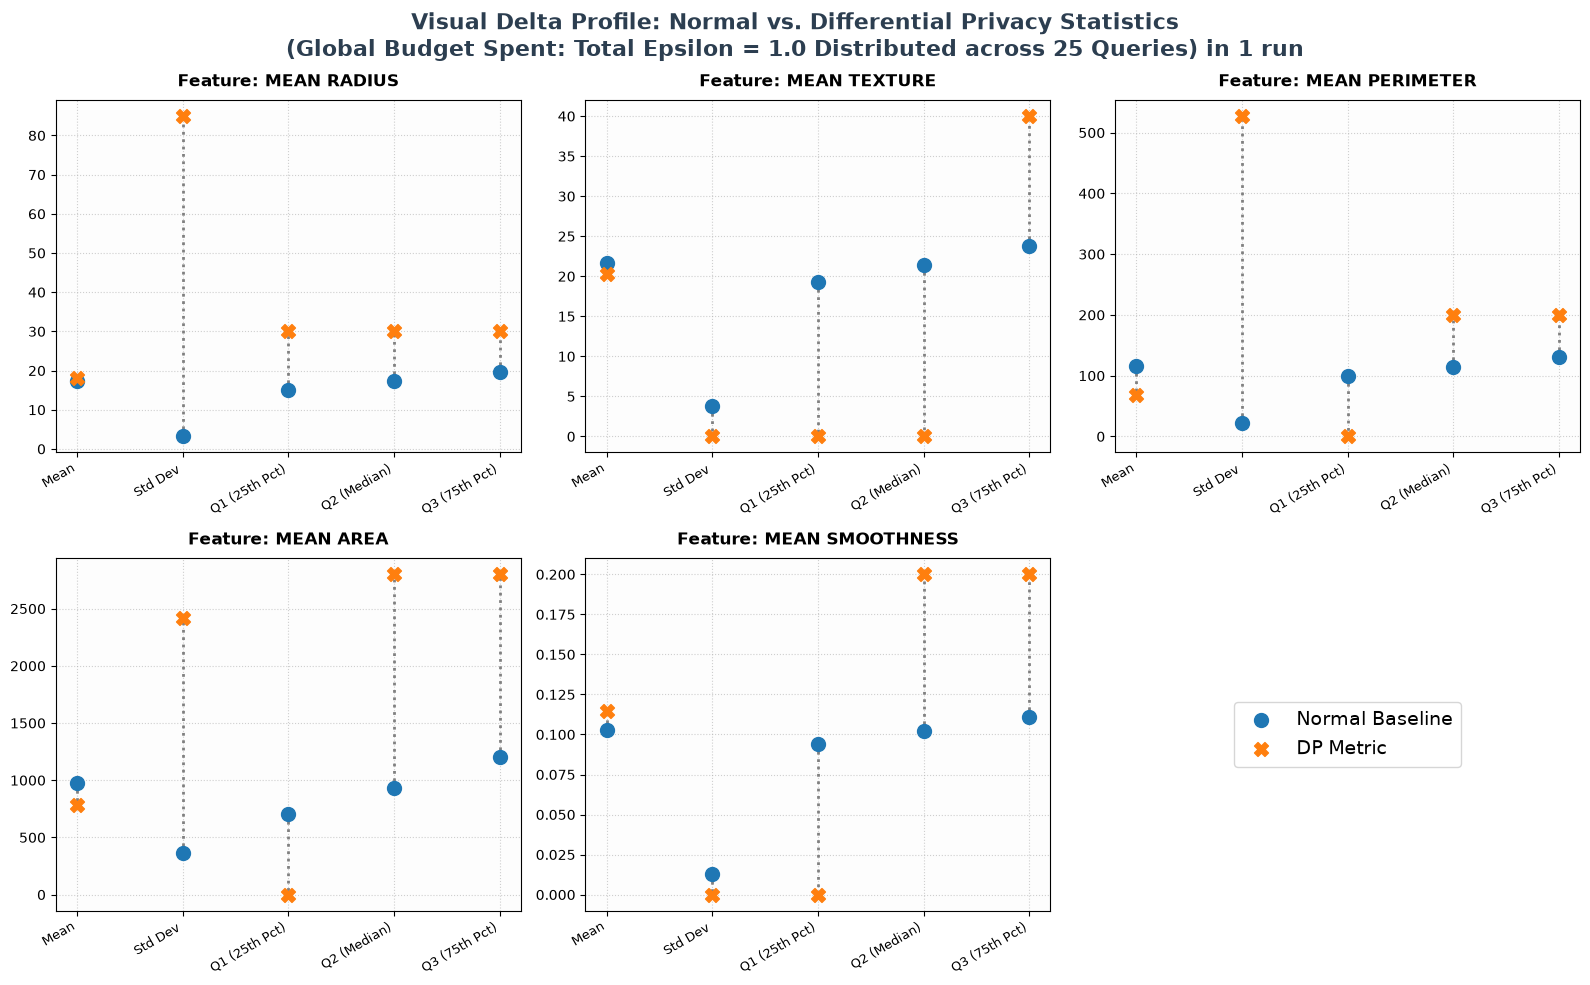

In [180]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten() # Flatten the 2D grid into a 1D list to loop through easily

for i, col in enumerate(features):
    ax = axes[i]
    
    # Extract values for the current feature
    true_vals = base_results[col]
    dp_vals = dp_results[col]
    
    x_indices = np.arange(len(stat_query))
    
    # 1. Plot the True Base Stats as solid Blue dots
    ax.scatter(x_indices, true_vals, color='#1f77b4', s=100, zorder=3, label='Normal Baseline')
    
    # 2. Plot the DP Stats as orange cross markers
    ax.scatter(x_indices, dp_vals, color='#ff7f0e', marker='X', s=100, zorder=3, label=f'DP Metric')
    
    # 3. Draw a vertical line connecting them (the "Error/Delta Bar")
    for idx in x_indices:
        ax.vlines(idx, true_vals[idx], dp_vals[idx], colors='gray', linestyles='dotted', lw=2)
        
    # Formatting each sub-graph
    ax.set_title(f"Feature: {col.upper()}", fontsize=12, fontweight='bold', pad=10)
    ax.set_xticks(x_indices)
    ax.set_xticklabels(stat_query, rotation=30, ha='right', fontsize=9)
    ax.grid(True, linestyle=':', alpha=0.6)
    
    # Add a subtle background shading to separate columns visually
    ax.set_facecolor('#fdfdfd')

# Handle the 6th empty subplot slot (since we only have 5 features)
axes[5].axis('off')
# Add a single master legend inside the empty space
axes[5].legend(*axes[0].get_legend_handles_labels(), loc='center', fontsize=14, frameon=True)

# Global layout styling
plt.suptitle(f"Visual Delta Profile: Normal vs. Differential Privacy Statistics\n(Global Budget Spent: Total Epsilon = {total_epsilon} Distributed across 25 Queries) in 1 run", 
             fontsize=16, fontweight='bold', color='#2c3e50')
plt.tight_layout()
plt.show()

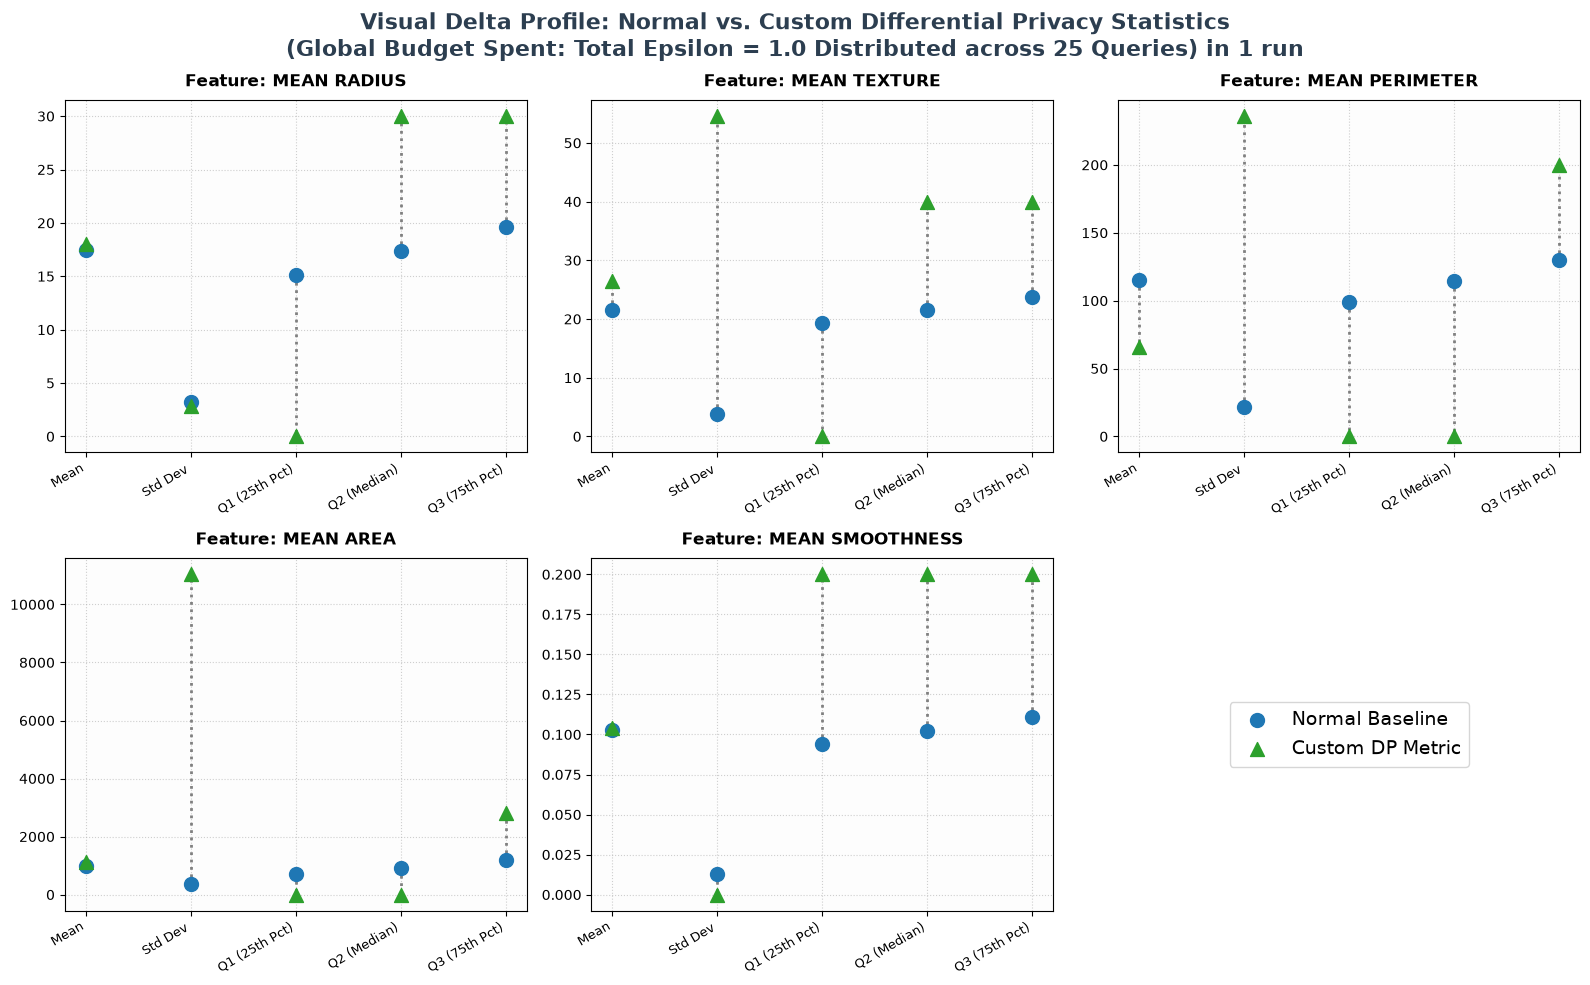

In [181]:
# baseline vs custom laplace
fig1, axes1 = plt.subplots(2, 3, figsize=(16, 10))
axes1 = axes1.flatten()

for i, col in enumerate(features):
    ax = axes1[i]
    true_vals = base_results[col]
    custom_vals = dp_with_custom_laplace[col]
    x_indices = np.arange(len(stat_query))
    
    # 1. Plot True Base Stats
    ax.scatter(x_indices, true_vals, color='#1f77b4', s=100, zorder=3, label='Normal Baseline')
    # 2. Plot Custom DP Stats
    ax.scatter(x_indices, custom_vals, color='#2ca02c', marker='^', s=100, zorder=3, label='Custom DP Metric')
    
    # 3. Draw vertical delta lines
    for idx in x_indices:
        ax.vlines(idx, true_vals[idx], custom_vals[idx], colors='gray', linestyles='dotted', lw=2)
        
    ax.set_title(f"Feature: {col.upper()}", fontsize=12, fontweight='bold', pad=10)
    ax.set_xticks(x_indices)
    ax.set_xticklabels(stat_query, rotation=30, ha='right', fontsize=9)
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.set_facecolor('#fdfdfd')

axes1[5].axis('off')
axes1[5].legend(*axes1[0].get_legend_handles_labels(), loc='center', fontsize=14, frameon=True)

plt.suptitle(f"Visual Delta Profile: Normal vs. Custom Differential Privacy Statistics\n(Global Budget Spent: Total Epsilon = {total_epsilon} Distributed across 25 Queries) in 1 run", 
             fontsize=16, fontweight='bold', color='#2c3e50')
plt.tight_layout()
plt.show()


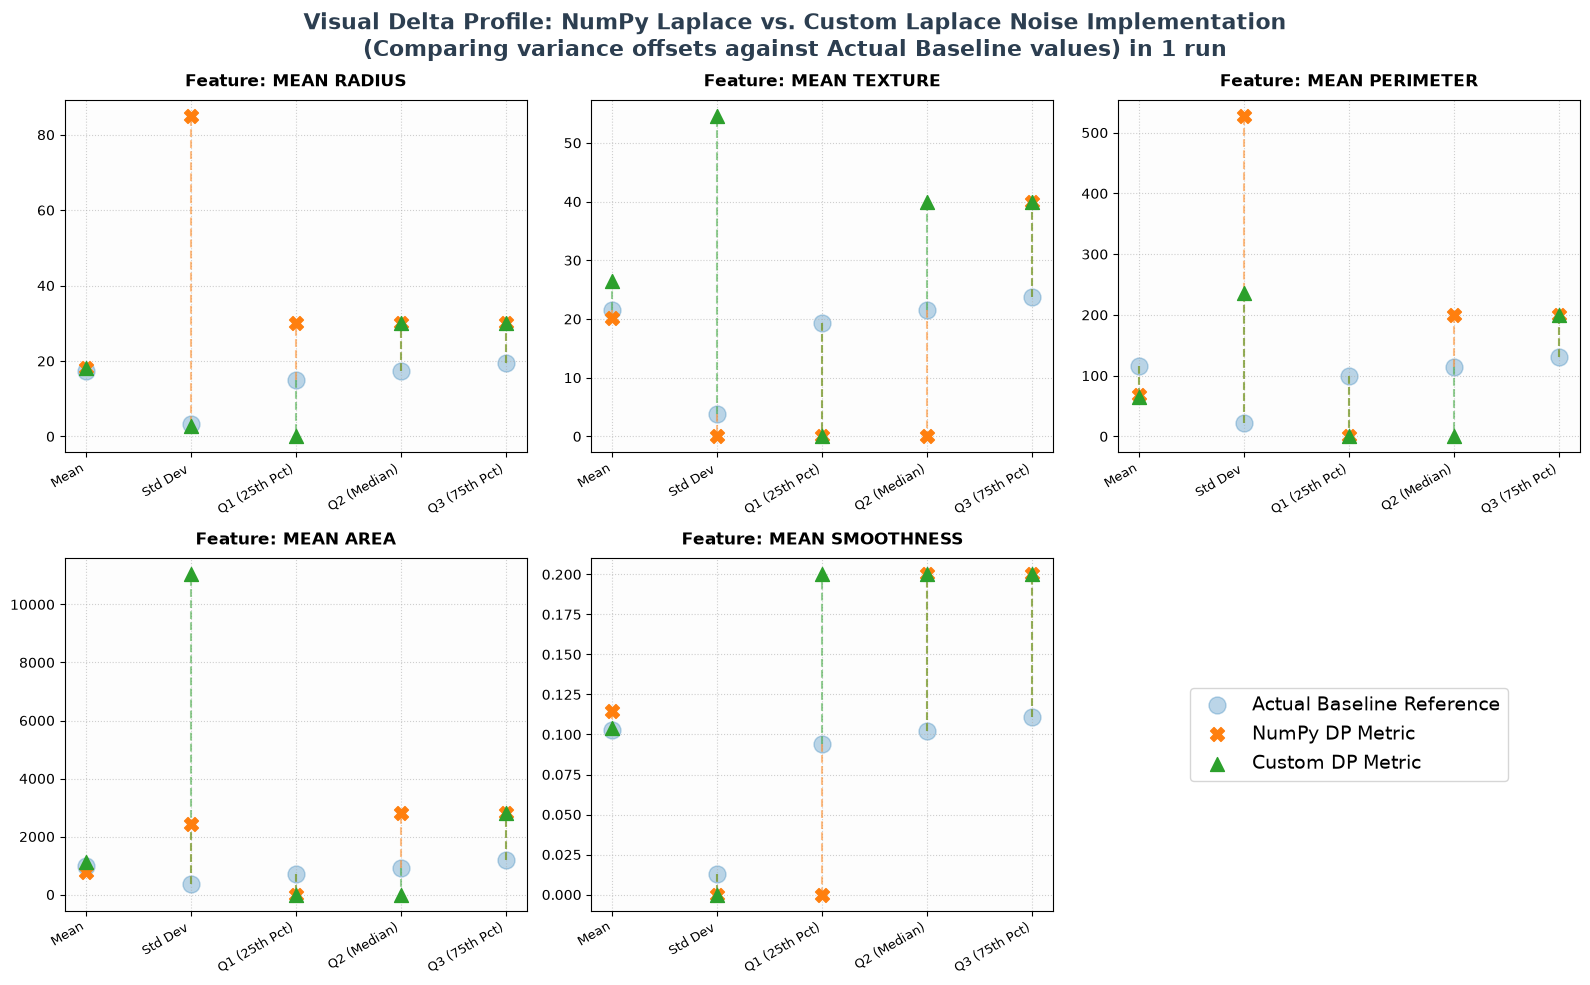

In [182]:
# numpy laplace vs custom laplace with baseline referece line

fig2, axes2 = plt.subplots(2, 3, figsize=(16, 10))
axes2 = axes2.flatten()

for i, col in enumerate(features):
    ax = axes2[i]
    true_vals = base_results[col]
    np_vals = dp_results[col]
    custom_vals = dp_with_custom_laplace[col]
    x_indices = np.arange(len(stat_query))
    
    # 1. Draw a horizontal baseline or reference area showing deviation from true data
    # We plot the true value as a reference line at each statistic's point
    ax.scatter(x_indices, true_vals, color='#1f77b4', alpha=0.3, s=150, zorder=1, label='Actual Baseline Reference')
    
    # 2. Plot NumPy DP Stats
    ax.scatter(x_indices, np_vals, color='#ff7f0e', marker='X', s=100, zorder=3, label='NumPy DP Metric')
    
    # 3. Plot Custom DP Stats
    ax.scatter(x_indices, custom_vals, color='#2ca02c', marker='^', s=100, zorder=3, label='Custom DP Metric')
    
    # 4. Draw vertical delta lines from both metrics to the baseline to show total error variance
    for idx in x_indices:
        ax.vlines(idx, true_vals[idx], np_vals[idx], colors='#ff7f0e', linestyles='dashed', alpha=0.5, lw=1.5)
        ax.vlines(idx, true_vals[idx], custom_vals[idx], colors='#2ca02c', linestyles='dashed', alpha=0.5, lw=1.5)
        
    ax.set_title(f"Feature: {col.upper()}", fontsize=12, fontweight='bold', pad=10)
    ax.set_xticks(x_indices)
    ax.set_xticklabels(stat_query, rotation=30, ha='right', fontsize=9)
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.set_facecolor('#fdfdfd')

axes2[5].axis('off')
axes2[5].legend(*axes2[0].get_legend_handles_labels(), loc='center', fontsize=14, frameon=True)

plt.suptitle(f"Visual Delta Profile: NumPy Laplace vs. Custom Laplace Noise Implementation\n(Comparing variance offsets against Actual Baseline values) in 1 run", 
             fontsize=16, fontweight='bold', color='#2c3e50')
plt.tight_layout()
plt.show()

### Comparing the three runs after doing 1000 runs. The plots are based on the median errors of all 1000 runs

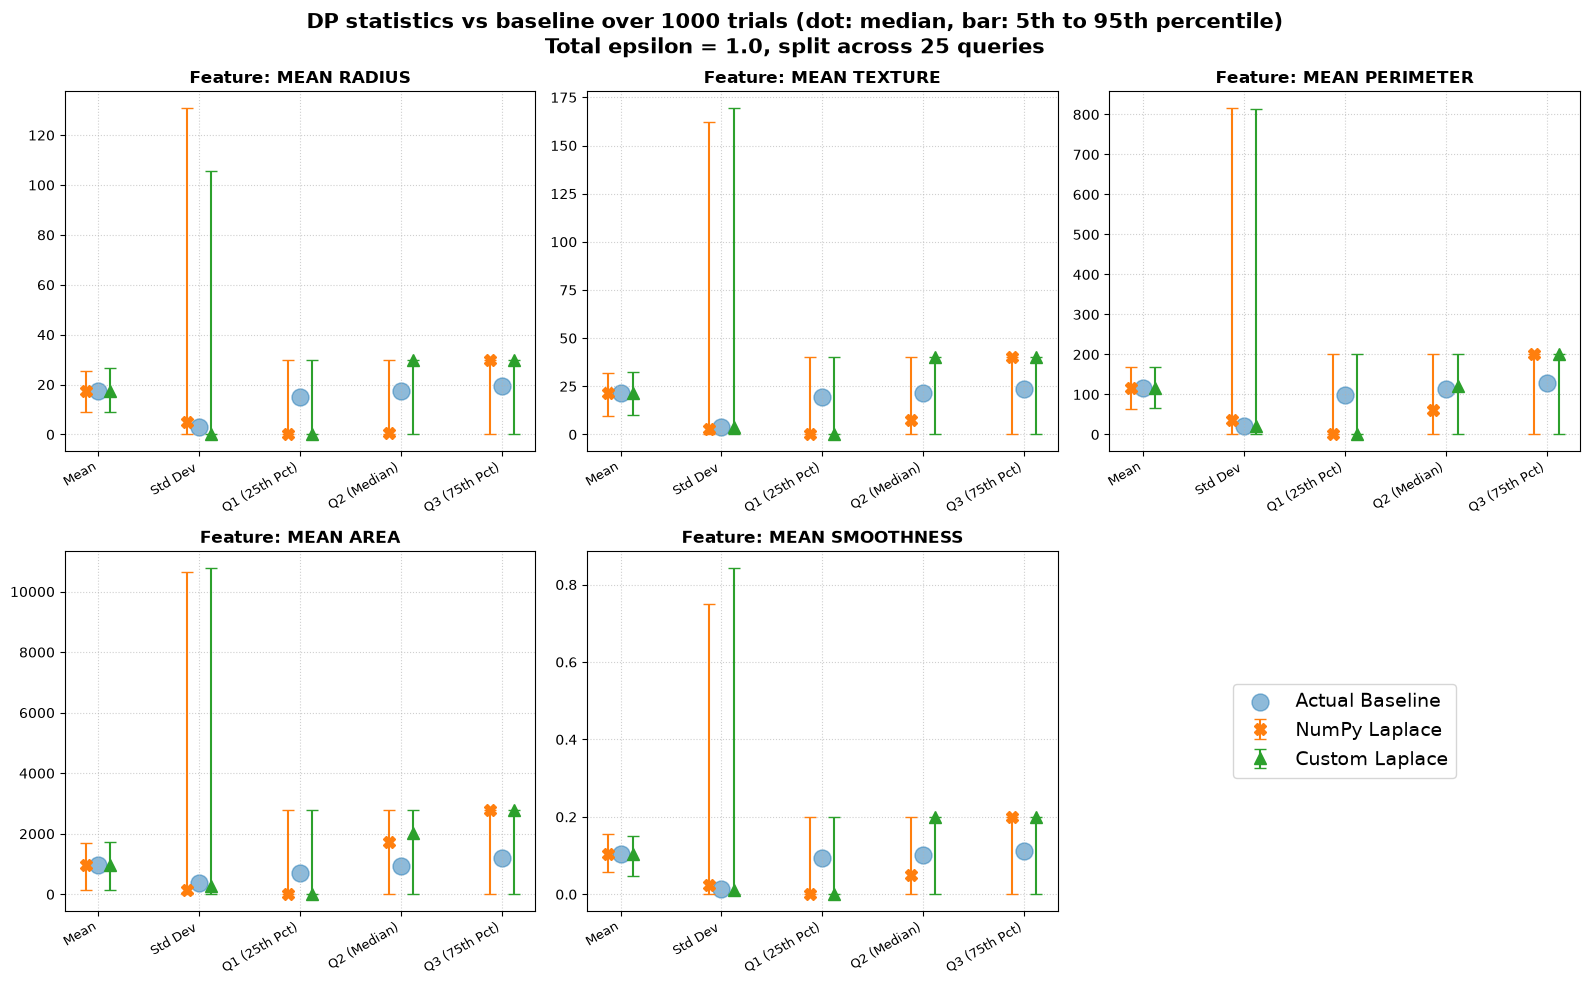

In [183]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()
x = np.arange(len(stat_query))

for i, col in enumerate(features):
    ax = axes[i]
    ax.scatter(x, base_results[col], color='#1f77b4', s=150, alpha=0.5, zorder=1, label='Actual Baseline')  # true values
    for name, runs, color, marker, shift in [('NumPy Laplace', numpy_dp_for_all, '#ff7f0e', 'X', -0.12),
                                             ('Custom Laplace', custom_dp_for_all, '#2ca02c', '^', 0.12)]:
        vals = np.array([t[col] for t in runs])             # shape: (trials, 5 stats)
        med = np.median(vals, axis=0)                       # typical DP value
        lo, hi = np.percentile(vals, [5, 95], axis=0)       # spread across trials
        ax.errorbar(x + shift, med, yerr=[med - lo, hi - med], fmt=marker, color=color,
                    capsize=4, markersize=8, label=name, zorder=3)

    ax.set_title(f"Feature: {col.upper()}", fontsize=12, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(stat_query, rotation=30, ha='right', fontsize=9)
    ax.grid(True, linestyle=':', alpha=0.6)

axes[5].axis('off')
axes[5].legend(*axes[0].get_legend_handles_labels(), loc='center', fontsize=14, frameon=True)
plt.suptitle(f"DP statistics vs baseline over {len(numpy_dp_for_all)} trials (dot: median, bar: 5th to 95th percentile)\nTotal epsilon = {total_epsilon}, split across 25 queries",
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

### Findings

- mean stays close to the true value on average, but any single noisy answer can still be far off
- Std and quartiles are mostly noise. Their sensitivities (R / sqrt(n) and R) are far bigger than the mean's (R / n), and many results hit the bounds after clipping
- numpy and custom Laplace functions performs the same way and give similr results
- Ways to improve: fewer queries, an uneven budget, tighter bounds, more data, or the exponential mechanism for quantiles.